# Cloud Models

Clouds are one of the most important sources of spectral degeneracy in exoplanet atmospheres: they suppress molecular features and make an atmosphere look featureless, regardless of its composition. This notebook extends the clear-sky transmission model from [Transmission spectrum basics](https://escience-taurex.github.io/taurex3/examples/03_transmission_basics.html) with three different cloud parameterisations, so you can see how each one imprints on the spectrum. The same sensitivity that makes clouds interesting also makes them a key consideration for the retrievals in [Fitting parameters and retrievals](https://escience-taurex.github.io/taurex3/examples/10_retrievals.html) — [Contribution analysis](https://escience-taurex.github.io/taurex3/examples/07_contribution_analysis.html) comes back to that from a contribution-analysis perspective.

TauREx provides three built-in cloud contributions:

- **`SimpleCloudsContribution`** — an opaque deck below a specified pressure level, blocking all radiation from deeper layers.
- **`FlatMieContribution`** — a grey (wavelength-independent) opacity layer between two pressure boundaries, with tunable strength.
- **`LeeMieContribution`** — wavelength-dependent Mie scattering using the [Lee et al. 2013](https://iopscience.iop.org/article/10.1088/0004-637X/778/2/97) formalism, parametrised by particle radius, extinction coefficient, and number density.

More information about cloud contributions and their parameter-file keywords is [here](../user/taurex/models.rst).

## Data Note

This notebook uses the opacity files set up in [Setup and opacity data](https://escience-taurex.github.io/taurex3/examples/01_setup_and_data.html). TauREx provides the software to work with these datasets; the files themselves are third-party products from [ExoMol](https://www.exomol.com).

In [1]:
from _shared import build_transmission_model
from taurex.contributions import SimpleCloudsContribution

clear_context = build_transmission_model(include_cia=False, include_rayleigh=True, download=False)
cloudy_context = build_transmission_model(
    include_cia=False,
    include_rayleigh=True,
    clouds=SimpleCloudsContribution(clouds_pressure=1e3),
    download=False,
    )

clear_tm = clear_context['tm']
cloudy_tm = cloudy_context['tm']

print('Clear contributions:', [c.name for c in clear_tm.contribution_list])
print('Cloudy contributions:', [c.name for c in cloudy_tm.contribution_list])

Clear contributions: ['Absorption', 'Rayleigh']
Cloudy contributions: ['SimpleClouds', 'Absorption', 'Rayleigh']


## Clear vs. Cloudy

Both forward models are built from identical atmospheric parameters — only the cloud deck differs. That isolation makes the spectral impact of the cloud immediately visible without any confounding differences.

In [2]:
clear_wngrid, clear_rprs, _, _ = clear_tm.model()
cloudy_wngrid, cloudy_rprs, _, _ = cloudy_tm.model()

wlgrid = 10000 / clear_wngrid[::-1]
clear_rprs = clear_rprs[::-1]
cloudy_rprs = cloudy_rprs[::-1]

print(f'Max cloud impact on transit depth: {(cloudy_rprs - clear_rprs).max():.3e}')

Max cloud impact on transit depth: 6.797e-04


In [3]:
difference = cloudy_rprs - clear_rprs
print(f'Mean cloud impact on transit depth: {difference.mean():.3e}')

Mean cloud impact on transit depth: 8.169e-05


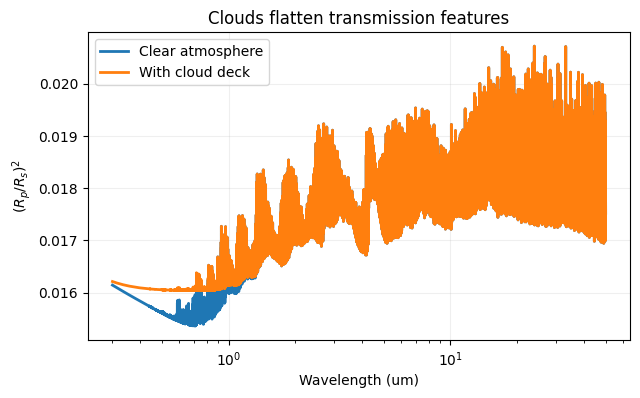

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(wlgrid, clear_rprs, label='Clear atmosphere', lw=2)
plt.plot(wlgrid, cloudy_rprs, label='With cloud deck', lw=2)
plt.xscale('log')
plt.xlabel('Wavelength (um)')
plt.ylabel('$(R_p/R_s)^2$')
plt.title('Clouds flatten transmission features')
plt.legend()
plt.grid(alpha=0.2)

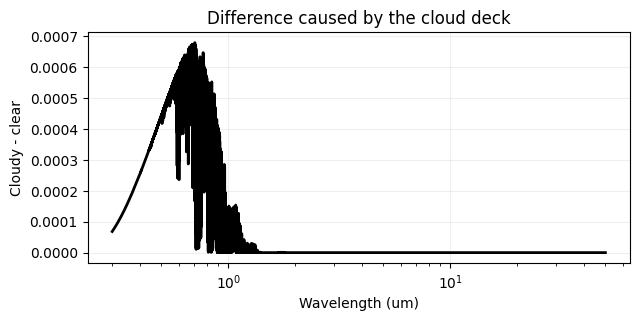

In [5]:
plt.figure(figsize=(7, 3))
plt.plot(wlgrid, difference, color='black', lw=2)
plt.xscale('log')
plt.xlabel('Wavelength (um)')
plt.ylabel('Cloudy - clear')
plt.title('Difference caused by the cloud deck')
plt.grid(alpha=0.2)

## Why Features Flatten

A cloud deck acts as a mirror in the atmosphere: it prevents photons from probing below a certain pressure level. Molecular features above the deck survive, but their contrast is reduced because the effective atmospheric path is shortened. This flattening is one of the central degeneracies in exoplanet retrieval — a featureless spectrum can mean either a clear, metal-poor atmosphere or a cloudy, gas-rich one.

More information about cloud contributions and where they sit in the retrieval context is [here](../user/taurex/models.rst).

## FlatMie: A Grey Cloud Layer

`FlatMieContribution` applies a wavelength-independent opacity between two pressure boundaries. Unlike `SimpleCloudsContribution`, it allows continuous tuning of the cloud strength via `flat_mix_ratio`, making it more suitable as a fitting parameter in retrievals.

Setting `flat_bottomP=-1` extends the layer all the way to the base of the atmosphere. More information about the model syntax is [here](../user/taurex/models.rst).

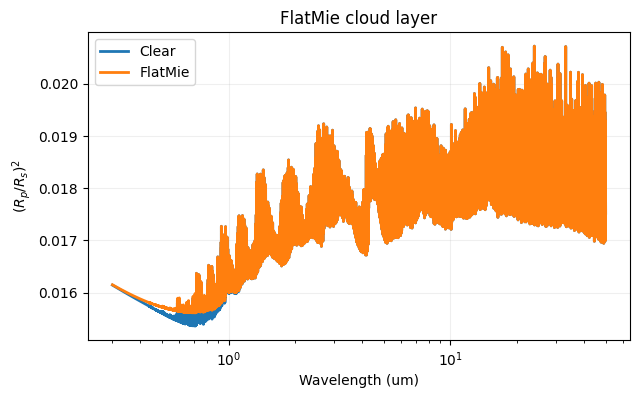

In [6]:
from taurex.contributions import FlatMieContribution

flatmie_context = build_transmission_model(
    include_cia=False,
    include_rayleigh=True,
    clouds=FlatMieContribution(flat_mix_ratio=1e-31, flat_bottomP=-1, flat_topP=1e3),
    download=False,
)
flatmie_tm = flatmie_context['tm']
_, flatmie_rprs, _, _ = flatmie_tm.model()
flatmie_rprs = flatmie_rprs[::-1]

plt.figure(figsize=(7, 4))
plt.plot(wlgrid, clear_rprs, lw=2, label='Clear')
plt.plot(wlgrid, flatmie_rprs, lw=2, label='FlatMie')
plt.xscale('log')
plt.xlabel('Wavelength (um)')
plt.ylabel('$(R_p/R_s)^2$')
plt.title('FlatMie cloud layer')
plt.legend()
plt.grid(alpha=0.2)

## LeeMie: Wavelength-Dependent Scattering

`LeeMieContribution` introduces particle-size-dependent opacity following the [Lee et al. 2013](https://iopscience.iop.org/article/10.1088/0004-637X/778/2/97) prescription. Unlike the grey models above, this produces a spectral slope: smaller particles scatter more at short wavelengths, producing a Rayleigh-like tilt, while larger particles give a flatter, greyer cloud signature.

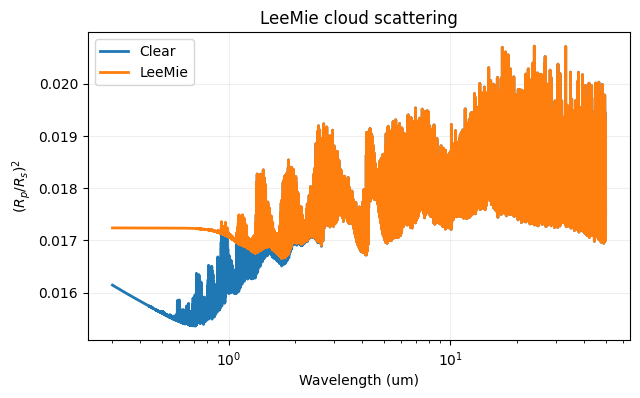

In [7]:
from taurex.contributions import LeeMieContribution

leemie_context = build_transmission_model(
    include_cia=False,
    include_rayleigh=True,
    clouds=LeeMieContribution(
        lee_mie_radius=0.01,
        lee_mie_q=40,
        lee_mie_mix_ratio=1e14,
        lee_mie_topP=1e1,
        lee_mie_bottomP=-1,
    ),
    download=False,
)
leemie_tm = leemie_context['tm']
_, leemie_rprs, _, _ = leemie_tm.model()
leemie_rprs = leemie_rprs[::-1]

plt.figure(figsize=(7, 4))
plt.plot(wlgrid, clear_rprs, lw=2, label='Clear')
plt.plot(wlgrid, leemie_rprs, lw=2, label='LeeMie')
plt.xscale('log')
plt.xlabel('Wavelength (um)')
plt.ylabel('$(R_p/R_s)^2$')
plt.title('LeeMie cloud scattering')
plt.legend()
plt.grid(alpha=0.2)